# Benchmarking OmniCloudMask Inference

This notebook measures how OmniCloudMask inference time scales with scene size across devices (CPU, CUDA, MPS) and data types (float32, float16, bfloat16). It:

1. Detects available devices and supported dtypes
2. Warms up each device/dtype combination
3. For each scene size, finds the optimal batch size then benchmarks with it
4. Reports mean and standard deviation over multiple runs
5. Compares GPU speedup vs CPU

In [1]:
import os
import platform
import time
from datetime import datetime, timezone

import numpy as np
import torch

import omnicloudmask
from omnicloudmask import predict_from_array

## 1. Detect available devices and dtypes

Automatically discover which devices are present and which inference dtypes each supports. Reduced precision (`float16` / `bfloat16`) is only tested on GPU — PyTorch lacks efficient CPU kernels for those types.

In [2]:
devices: list[str] = ["cpu"]
if torch.cuda.is_available():
    devices.append("cuda")
if torch.backends.mps.is_available():
    devices.append("mps")

# Reduced precision is only beneficial on GPU — skip it for CPU.
# Only float16 is tested (not bfloat16) as they have equivalent throughput
# on modern GPUs and float16 has broader hardware support.
DTYPES: dict[str, list[torch.dtype]] = {}
for dev in devices:
    if dev == "cpu":
        DTYPES[dev] = [torch.float32]
    elif dev == "cuda":
        DTYPES[dev] = [torch.float32, torch.float16]
    elif dev == "mps":
        DTYPES[dev] = [torch.float32, torch.float16]

SCENE_SIZES: dict[str, list[int]] = {
    "cpu": [100, 250, 500, 1000],
    "cuda": [100, 250, 500, 1000, 2000, 3000, 5000],
    "mps": [100, 250, 500, 1000, 2000, 3000, 5000],
}
BATCH_SIZES: dict[str, list[int]] = {
    "cpu": [1, 2, 4, 8],
    "cuda": [1, 2, 4, 8, 16],
    "mps": [1, 2, 4, 8, 16],
}
# More repeats for small scenes where system jitter dominates
REPEATS_SMALL = 6  # scenes <= 500 px
REPEATS_LARGE = 3  # scenes > 500 px
BS_SEARCH_REPEATS = 3


def get_cpu_name() -> str:
    """Get CPU model name from /proc/cpuinfo or platform."""
    try:
        with open("/proc/cpuinfo") as f:
            for line in f:
                if line.startswith("model name"):
                    return line.split(":")[1].strip()
    except FileNotFoundError:
        pass
    return platform.processor() or "Unknown"


def get_ram_gb() -> float:
    """Get total system RAM in GB using stdlib only."""
    try:
        pages = os.sysconf("SC_PHYS_PAGES")
        page_size = os.sysconf("SC_PAGE_SIZE")
        return round(pages * page_size / (1024**3), 1)
    except (ValueError, OSError):
        return 0.0


# Machine fingerprint for reproducibility and cross-platform comparison
fingerprint: dict = {
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "omnicloudmask_version": omnicloudmask.__version__,
    "pytorch_version": torch.__version__,
    "os": f"{platform.system()} {platform.release()}",
    "python_version": platform.python_version(),
    "cpu": get_cpu_name(),
    "ram_gb": get_ram_gb(),
}
if torch.cuda.is_available():
    fingerprint["cuda_version"] = torch.version.cuda
    fingerprint["gpu"] = torch.cuda.get_device_name(0)
    fingerprint["gpu_memory_gb"] = round(
        torch.cuda.get_device_properties(0).total_memory / (1024**3), 1
    )
if torch.backends.mps.is_available():
    fingerprint["gpu"] = "Apple MPS"

for k, v in fingerprint.items():
    print(f"{k:>22} : {v}")
print()
print(f"Devices         : {', '.join(devices)}")
for dev in devices:
    dtypes_str = ", ".join(str(d).split(".")[-1] for d in DTYPES[dev])
    print(f"  {dev:>5} dtypes  : {dtypes_str}")
    print(f"  {dev:>5} scenes  : {SCENE_SIZES[dev]}")
    print(f"  {dev:>5} batches : {BATCH_SIZES[dev]}")
print(f"Repeats         : {REPEATS_SMALL} (<=500px), {REPEATS_LARGE} (>500px)")
print(f"BS search runs  : {BS_SEARCH_REPEATS}")

             timestamp : 2026-03-25T03:49:40.768368+00:00
 omnicloudmask_version : 1.7.1
       pytorch_version : 2.9.1+cu128
                    os : Linux 6.8.0-106-generic
        python_version : 3.12.11
                   cpu : AMD Ryzen 9 5950X 16-Core Processor
                ram_gb : 125.7
          cuda_version : 12.8
                   gpu : NVIDIA GeForce RTX 4090
         gpu_memory_gb : 23.5

Devices         : cpu, cuda
    cpu dtypes  : float32
    cpu scenes  : [100, 250, 500, 1000]
    cpu batches : [1, 2, 4, 8]
   cuda dtypes  : float32, float16
   cuda scenes  : [100, 250, 500, 1000, 2000, 3000, 5000]
   cuda batches : [1, 2, 4, 8, 16]
Repeats         : 6 (<=500px), 3 (>500px)
BS search runs  : 3


## 2. Helper functions

- `make_scene` generates a synthetic `(3, H, W)` uint16 array (Red, Green, NIR) with a fixed seed for reproducibility
- `sync_device` ensures GPU work is complete before timing
- `timed_predict` runs a single inference call and returns wall-clock seconds. For scenes smaller than 1000 px the patch size is set to the scene size; larger scenes use the default 1000 px patches with 300 px overlap
- `find_optimal_batch_size` tries each candidate batch size for a given scene using the median of multiple runs, and returns the fastest one, stopping early on OOM

In [3]:
def make_scene(size: int) -> np.ndarray:
    """Synthetic (3, H, W) uint16 array — Red, Green, NIR.

    Uses a fixed seed so every scene has identical statistical properties,
    ensuring timing differences reflect compute cost, not data variation.
    """
    rng = np.random.default_rng(42)
    return rng.integers(100, 4000, size=(3, size, size), dtype=np.uint16)


def sync_device(device: str) -> None:
    """Block until all queued GPU work finishes, so timings are accurate."""
    if device == "cuda":
        torch.cuda.synchronize()
    elif device == "mps":
        torch.mps.synchronize()


def timed_predict(
    scene: np.ndarray,
    batch_size: int,
    device: str,
    dtype: torch.dtype,
) -> float:
    """Run a single prediction and return wall-clock seconds."""
    scene_size = scene.shape[-1]
    patch_size = min(scene_size, 1000)
    patch_overlap = 0 if scene_size <= 1000 else 300
    sync_device(device)
    t0 = time.perf_counter()
    predict_from_array(
        input_array=scene,
        patch_size=patch_size,
        patch_overlap=patch_overlap,
        batch_size=batch_size,
        inference_device=device,
        mosaic_device=device,
        inference_dtype=dtype,
    )
    sync_device(device)
    return time.perf_counter() - t0


def find_optimal_batch_size(
    scene: np.ndarray,
    device: str,
    dtype: torch.dtype,
) -> int:
    """Try each candidate batch size and return the fastest.

    Each batch size is warmed up before timing. The median of
    BS_SEARCH_REPEATS timed runs is used to reduce noise.
    """
    best_bs = 1
    best_time = float("inf")

    for bs in BATCH_SIZES[device]:
        try:
            # Warm up this batch size
            timed_predict(scene, batch_size=bs, device=device, dtype=dtype)
            # Median of multiple timed runs to reduce noise
            times = [
                timed_predict(scene, batch_size=bs, device=device, dtype=dtype)
                for _ in range(BS_SEARCH_REPEATS)
            ]
            t = float(np.median(times))
            if t < best_time:
                best_time = t
                best_bs = bs
        except RuntimeError as e:
            if (
                "out of memory" in str(e).lower()
                or "not enough memory" in str(e).lower()
            ):
                if device == "cuda":
                    torch.cuda.empty_cache()
                break
            raise
    return best_bs

## 3. Benchmark across scene sizes

For each device/dtype/scene-size combination: warm up, find the optimal batch size, then run timed repeats. Scenes are pre-generated so array creation time is excluded. Mean and standard deviation are reported along with the chosen batch size.

In [4]:
# Pre-generate all scenes so array creation isn't included in timings
all_sizes = sorted(set(s for sizes in SCENE_SIZES.values() for s in sizes))
scenes: dict[int, np.ndarray] = {size: make_scene(size) for size in all_sizes}
warmup_scene = make_scene(64)

# results[(device, dtype)] = list of (size, pixels, mean_s, std_s, px_per_s, bs)
results: dict[tuple[str, torch.dtype], list[tuple]] = {}

for device in devices:
    for dtype in DTYPES[device]:
        dtype_name = str(dtype).split(".")[-1]
        key = (device, dtype)

        # Warm up this device/dtype before any timing
        timed_predict(warmup_scene, batch_size=1, device=device, dtype=dtype)

        print(f"\n{device} / {dtype_name}")
        print(
            f"{'size':>10}  {'pixels':>14}  {'bs':>4}  {'reps':>4}"
            f"  {'mean_s':>8}  {'std_s':>8}  {'px/s':>14}"
        )
        print("-" * 74)

        config_results = []
        for size in SCENE_SIZES[device]:
            scene = scenes[size]
            repeats = REPEATS_SMALL if size <= 500 else REPEATS_LARGE

            # Only one patch when scene <= 1000 px, so bs=1
            if size <= 1000:
                bs = 1
            else:
                bs = find_optimal_batch_size(scene, device, dtype)

            # Warmup with chosen batch size, then time
            timed_predict(scene, batch_size=bs, device=device, dtype=dtype)

            times = []
            for _ in range(repeats):
                t = timed_predict(scene, batch_size=bs, device=device, dtype=dtype)
                times.append(t)
            mean_s = float(np.mean(times))
            std_s = float(np.std(times, ddof=1))
            pixels = size * size
            px_per_s = pixels / mean_s
            config_results.append((size, pixels, mean_s, std_s, px_per_s, bs))
            print(
                f"{size:>10}  {pixels:>14,}  {bs:>4}  {repeats:>4}"
                f"  {mean_s:>8.3f}  {std_s:>8.3f}  {px_per_s:>14,.0f}"
            )

        results[key] = config_results


cpu / float32
      size          pixels    bs  reps    mean_s     std_s            px/s
--------------------------------------------------------------------------
       100          10,000     1     6     0.030     0.001         333,243
       250          62,500     1     6     0.070     0.004         897,684
       500         250,000     1     6     0.200     0.009       1,250,236
      1000       1,000,000     1     3     1.133     0.044         882,290

cuda / float32
      size          pixels    bs  reps    mean_s     std_s            px/s
--------------------------------------------------------------------------
       100          10,000     1     6     0.013     0.001         768,338
       250          62,500     1     6     0.014     0.001       4,368,745
       500         250,000     1     6     0.017     0.001      14,934,081
      1000       1,000,000     1     3     0.038     0.001      26,070,770
      2000       4,000,000     2     3     0.216     0.002      18,54

## 4. Speedup comparison

Compare each GPU device/dtype configuration against the CPU float32 baseline at every scene size.

In [5]:
cpu_baseline_key = ("cpu", torch.float32)

if cpu_baseline_key in results and len(results) > 1:
    cpu_by_size = {r[0]: r for r in results[cpu_baseline_key]}

    for key, data in results.items():
        if key == cpu_baseline_key:
            continue
        device, dtype = key
        dtype_name = str(dtype).split(".")[-1]
        label = f"{device}/{dtype_name}"
        print(f"\n--- Speedup: {label} vs cpu/float32 ---")
        print(f"{'size':>10}  {'cpu_s':>8}  {'other_s':>8}  {'speedup':>8}")
        print("-" * 40)
        for r in data:
            size = r[0]
            if size in cpu_by_size:
                cpu_r = cpu_by_size[size]
                speedup = cpu_r[2] / r[2]
                print(f"{size:>10}  {cpu_r[2]:>8.3f}  {r[2]:>8.3f}  {speedup:>7.1f}x")
            else:
                print(f"{size:>10}  {'n/a':>8}  {r[2]:>8.3f}      —")
else:
    print("Only one configuration available — no speedup comparison.")


--- Speedup: cuda/float32 vs cpu/float32 ---
      size     cpu_s   other_s   speedup
----------------------------------------
       100     0.030     0.013      2.3x
       250     0.070     0.014      4.9x
       500     0.200     0.017     11.9x
      1000     1.133     0.038     29.5x
      2000       n/a     0.216      —
      3000       n/a     0.389      —
      5000       n/a     1.065      —

--- Speedup: cuda/float16 vs cpu/float32 ---
      size     cpu_s   other_s   speedup
----------------------------------------
       100     0.030     0.014      2.1x
       250     0.070     0.015      4.6x
       500     0.200     0.019     10.8x
      1000     1.133     0.036     31.6x
      2000       n/a     0.169      —
      3000       n/a     0.283      —
      5000       n/a     0.869      —


## 5. Visualise

Throughput (pixels/second) and inference time vs scene size for each device/dtype combination, with error bars showing +/- 1 standard deviation.

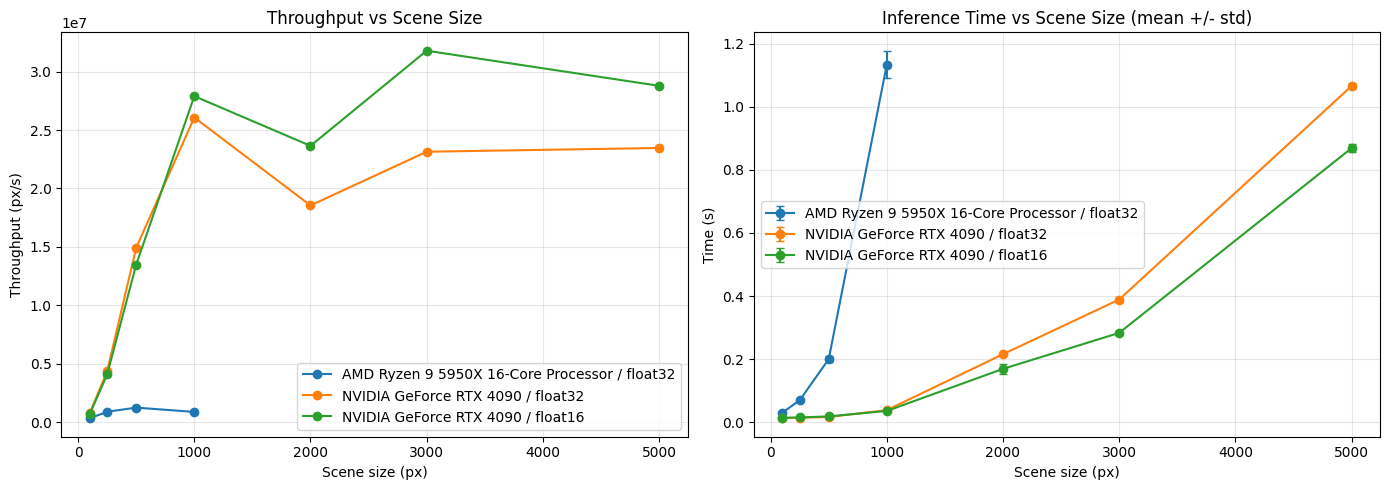

In [6]:
import matplotlib.pyplot as plt

# Build device name mapping for legends
device_names: dict[str, str] = {"cpu": get_cpu_name()}
if torch.cuda.is_available():
    device_names["cuda"] = torch.cuda.get_device_name(0)
if torch.backends.mps.is_available():
    device_names["mps"] = "Apple MPS"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for key, data in results.items():
    device, dtype = key
    dtype_name = str(dtype).split(".")[-1]
    hw_name = device_names.get(device, device)
    label = f"{hw_name} / {dtype_name}"
    sizes = [r[0] for r in data]
    px_per_s = [r[4] for r in data]
    mean_times = [r[2] for r in data]
    std_times = [r[3] for r in data]

    ax1.plot(sizes, px_per_s, "o-", label=label)
    ax2.errorbar(sizes, mean_times, yerr=std_times, fmt="o-", label=label, capsize=3)

ax1.set_xlabel("Scene size (px)")
ax1.set_ylabel("Throughput (px/s)")
ax1.set_title("Throughput vs Scene Size")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Scene size (px)")
ax2.set_ylabel("Time (s)")
ax2.set_title("Inference Time vs Scene Size (mean +/- std)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Export results

Save the machine fingerprint and all benchmark results to a JSON file. The filename includes the CPU/GPU name and timestamp so results from different platforms can be collected in a `benchmarks/results/` directory for comparison.

In [ ]:
import json
import re
from pathlib import Path

# Build export structure
export: dict = {
    "fingerprint": fingerprint,
    "settings": {
        "repeats_small": REPEATS_SMALL,
        "repeats_large": REPEATS_LARGE,
        "bs_search_repeats": BS_SEARCH_REPEATS,
    },
    "results": [],
}

cpu_baseline = {r[0]: r[2] for r in results.get(("cpu", torch.float32), [])}

for (device, dtype), data in results.items():
    dtype_name = str(dtype).split(".")[-1]
    for size, pixels, mean_s, std_s, px_per_s, bs in data:
        entry: dict = {
            "device": device,
            "dtype": dtype_name,
            "scene_size": size,
            "pixels": pixels,
            "batch_size": bs,
            "mean_seconds": round(mean_s, 4),
            "std_seconds": round(std_s, 4),
            "pixels_per_second": round(px_per_s),
        }
        if device != "cpu" and size in cpu_baseline:
            entry["speedup_vs_cpu"] = round(cpu_baseline[size] / mean_s, 2)
        export["results"].append(entry)

# Generate a filename from the primary hardware
hw_tag = fingerprint.get("gpu", fingerprint["cpu"])
hw_tag = re.sub(r"[^\w]+", "_", hw_tag).strip("_").lower()
ts = datetime.now(timezone.utc).strftime("%Y%m%d")
out_dir = Path.cwd() / "results"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f"{hw_tag}_{ts}.json"

out_path.write_text(json.dumps(export, indent=2) + "\n")
print(f"Saved: {out_path}")
print(f"  {len(export['results'])} result rows across {len(results)} configurations")

Saved: benchmarks/results/nvidia_geforce_rtx_4090_20260325.json
  18 result rows across 3 configurations
